In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.preprocessing import QuantileTransformer

In [3]:
df = pd.read_csv('./data/titanic_clean.csv')

Feature Engineering

Al momento de entrenar un modelo de machine learning, es común que tengamos la necesidad de crear nuevas variables. Un ejemplo de esto podría ser en un modelo de predicción de ventas, donde podríamos crear una nueva variable que represente el día de la semana a partir de una columna de fechas, ya que las ventas pueden variar significativamente entre días laborables y fines de semana.

Antes de fature engineering

Scikit Learn LabelEncoder

Scikit Learn es la librería por excelencia para hacer aprendizaje automático en Python. Este paquete cuenta con una clase LabelEncoder que se utiliza justamente para convertir variables categóricas a numéricas. 

In [4]:
from sklearn.preprocessing import LabelEncoder

# Datos categóricos de ejemplo
animales = ['gato', 'perro', 'pez', 'gato', 'perro']

# Crear una instancia de LabelEncoder
le = LabelEncoder()

# Ajustar y transformar los datos
animales_codificados = le.fit_transform(animales)

# Mostrar los datos codificados
print(animales_codificados)

# Si deseas ver cómo se mapean las etiquetas originales
print(list(le.classes_))

[0 1 2 0 1]
[np.str_('gato'), np.str_('perro'), np.str_('pez')]


Codificación de Sex y Embarked

In [5]:
label_sex = LabelEncoder()
label_embarked = LabelEncoder()

# Fit and transform on training data
df['Sex'] = label_sex.fit_transform(df['Sex'])
df['Embarked'] = label_embarked.fit_transform(df['Embarked'])

Sí… es así de simple. Ahora veamos df

In [6]:
df.sample(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
604,1,1,1,35.0,0,0,26.5500,0
582,0,2,1,54.0,0,0,26.0000,2
468,0,3,1,NaN,0,0,7.7250,1
3,1,1,0,35.0,1,0,53.1000,2
496,1,1,0,54.0,1,0,78.2667,0


Tenemos dos variables numéricas cuyos rangos y distrubución no es ideal.

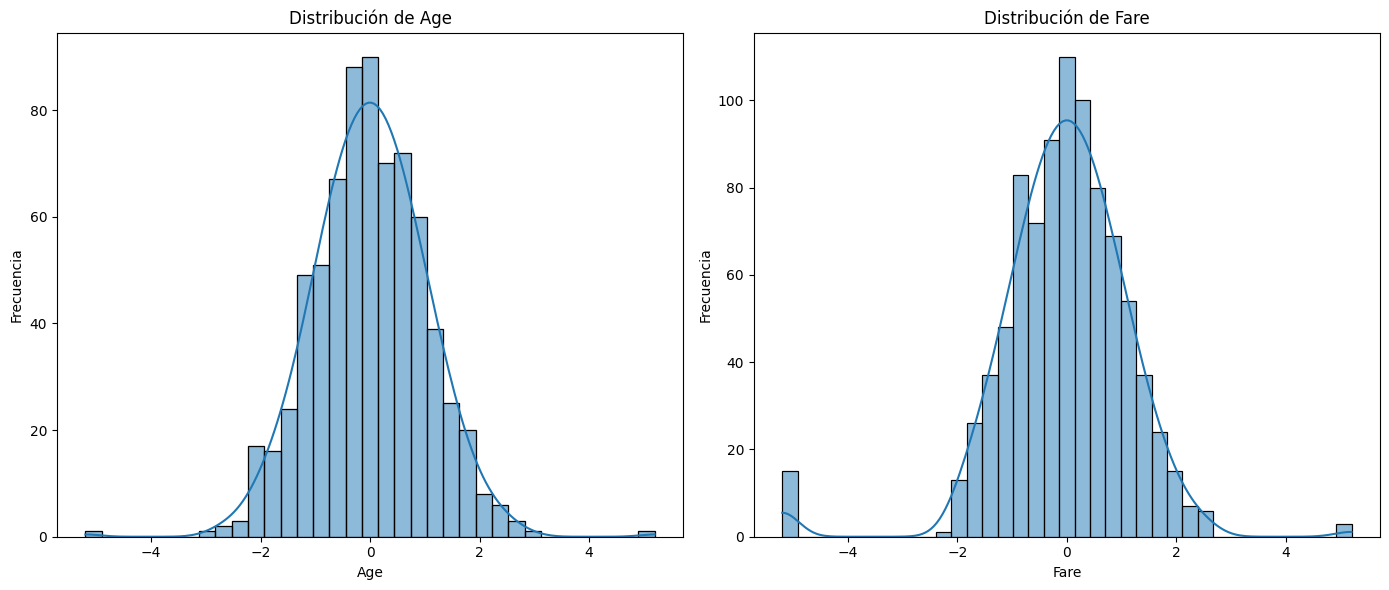

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sns.histplot(df['Age'].dropna(), kde=True, ax=axes[0])
axes[0].set_title('Distribución de Age')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Frecuencia')

# Gráfica de la distribución de Fare
sns.histplot(df['Fare'].dropna(), kde=True, ax=axes[1])
axes[1].set_title('Distribución de Fare')
axes[1].set_xlabel('Fare')
axes[1].set_ylabel('Frecuencia')

# Mostrar las gráficas
plt.tight_layout()
plt.show()

El QuantileTransformer es una herramienta de Scikit-Learn que transforma los datos para que sigan una distribución uniforme o normal. Esto se logra ajustando los valores de los datos según sus cuantiles, lo que puede reducir el impacto de los valores atípicos y mejorar el rendimiento de los algoritmos de aprendizaje automático.

Usar QuantileTransformer de Scikit-Learn para normalizar Age y Fare es una buena idea porque transforma las características a una distribución uniforme o normal, lo cual es especialmente útil para manejar características con distribuciones muy sesgadas o con valores atípicos. Dado que Fare tiene una distribución altamente sesgada con una larga cola, QuantileTransformer puede redistribuir los datos de manera más equitativa.

In [8]:
qun_tra_age = QuantileTransformer(output_distribution = 'normal', n_quantiles=500)
qun_tra_fare = QuantileTransformer(output_distribution = 'normal', n_quantiles=500)

df['Age'] = qun_tra_age.fit_transform(df[['Age']])
df['Fare'] = qun_tra_fare.fit_transform(df[['Fare']])

In [10]:
mms_pclass= MinMaxScaler()
mms_sex = MinMaxScaler()
mms_age = MinMaxScaler()
mms_sibsp = MinMaxScaler()
mms_parch = MinMaxScaler()
mms_fare = MinMaxScaler()
mms_embarked = MinMaxScaler()

# Ejecutar transformaciones
df['Pclass'] = mms_pclass.fit_transform(df[['Pclass']])
df['Sex'] = mms_sex.fit_transform(df[['Sex']])
df['Age'] = mms_age.fit_transform(df[['Age']])
df['SibSp'] = mms_sibsp.fit_transform(df[['SibSp']])
df['Parch'] = mms_parch.fit_transform(df[['Parch']])
df['Fare'] = mms_fare.fit_transform(df[['Fare']])
df['Embarked'] = mms_embarked.fit_transform(df[['Embarked']])

In [11]:
df.sample(5)

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
759,1,0.0,0.0,0.534029,0.000,0.0,0.640403,1.0
770,0,1.0,1.0,0.467254,0.000,0.0,0.466485,1.0
625,0,0.0,1.0,0.683693,0.000,0.0,0.569367,1.0
664,1,1.0,1.0,0.431916,0.125,0.0,0.438286,1.0
308,0,0.5,1.0,0.513327,0.125,0.0,0.528175,0.0


Checkpoint

Normalmente podríamos continuar haciendo todo en el mismo Notebook, pero hagamos un checkpoint aquí. Guardemos nuestro conjunto de datos y continuemos al siguiente notebook 4_machine_learning.ipynb

In [12]:
df.to_csv('./data/titanic_procesado.csv', index=False)